---
title: "📐The Hidden Geometry of Software Coupling (Part 1)"
date: 2026-03-09 00:11:50 -0500
categories:
  - sdlc
  - architecture
  - coupling
  - metrics
author: steven
---

# 📐 The Hidden Geometry of Software Coupling
### Part 1 — The Metrics That Predict Architectural Failure


In [7]:
# ============================================================
# SETUP — Run this first!
# ============================================================

# Install plotly if needed (uncomment):
# !pip install  plotly pandas

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np

print("✅ Plotly version:", go.__version__ if hasattr(go, '__version__') else 'installed')
print("✅ matplotlib version:", mpl.__version__ if hasattr(mpl, '__version__') else 'installed')
print("✅ Setup complete!")

# ============================================================
# 🎨 CONFIGURATION
# ============================================================

CONFIG = {
    # Background colors
    'paper_bg': '#FCF5E5',
    'plot_bg': 'rgba(252,245,229,0.8)',

    # Instability colorscale (list of [position, color])
    # Position: 0.0 to 1.0, Color: any CSS color
    'instability_colorscale': [
        [0.00, '#FFFFFF'],   # White at I=0
        [0.05, '#6AD8D8'],   # Light teal
        [0.20, '#0D3D3D'],   # Dark teal
        [0.30, '#E0B060'],   # Light bronze
        [0.45, '#5A3A12'],   # Dark bronze
        [0.50, '#3A0808'],   # Darkest red (center)
        [0.55, '#E89048'],   # Light copper
        [0.70, '#6A3210'],   # Dark copper
        [0.80, '#8A4A9A'],   # Light purple
        [0.95, '#2A0A3A'],   # Dark purple
        [1.00, '#000000'],   # Black at I=1
    ],

    # Distance colorscale (green=good, red=bad)
    'distance_colorscale': [
        [0.0, '#2E7D32'],    # Dark green (D=0, ideal)
        [0.2, '#4CAF50'],    # Green
        [0.4, '#8BC34A'],    # Light green
        [0.5, '#FFEB3B'],    # Yellow
        [0.7, '#FF9800'],    # Orange
        [0.85, '#F44336'],   # Red
        [1.0, '#B71C1C'],    # Dark red (D=1, worst)
    ],

    # Zone colors for Main Sequence
    'zone_pain': 'rgba(232,180,180,0.6)',
    'zone_useless': 'rgba(180,180,232,0.6)',
    'main_seq': '#4CAF50',

    # Default camera for 3D plots
    'camera': dict(
        eye=dict(x=1.5, y=1.5, z=1.2),
        up=dict(x=0, y=0, z=1)
    ),

    # Mesh resolution
    'mesh_points': 100,  # Lower than matplotlib for performance
}

print("🎨 Configuration loaded")

✅ Plotly version: installed
✅ matplotlib version: 3.10.8
✅ Setup complete!
🎨 Configuration loaded


## 📃Introduction

Software engineers love to talk about architecture in qualitative terms.

- *“This module feels tightly coupled.”*
- *“That dependency seems risky.”*
- *“This design is flexible.”*

But beneath those instincts lies something far more concrete.

The **structure of software systems can be measured**.

And those measurements often predict architectural problems **long before production failures reveal them**.

The formulas behind these metrics have been around since the 1990s.
They require no machine learning.

Just counting.

And occasionally a little division.


## 🗿The Architecture That Was “Good Enough”… Until It Opened a Hellmouth 👹

>For the first six months, everything felt fast.  Our Ruby-on-Rails application was humming along:

* Features shipped quickly.
* Bug fixes took hours, not days.
* Engineers felt productive.

_Then, something strange started happening; it began to shift:_
* A simple change began taking longer.
* A feature that should have touched one component suddenly required edits across:
  - seemingly-unrelated models and controllers
  - background jobs
  - serializers
  - service classes
  - many tests scattered across the codebase, some that seem unrelated.

_Then the real symptoms appeared:_
* New engineers joined the team and couldn't make heads or tails of the system.
* Bug fixes triggered unrelated failures.
* A “small refactor” broke three features nobody expected to be connected.
* Every change started to feel dangerous.

Eventually they bring in an architect who spends a bit of time assembling tools needwd to gather the appropriate metrics and report on them (over time, assuming use of SCM)

Later they are told:
> “Your problem isn’t Rails. Your problem is **coupling**."
> Here are your danger areas from worst to least.

Some people remember this from _Software Engineering Principles_ (or whatever the course/book/article you read about this).  It maybe have come up a few times since, but never _exactly quantified_.  Now here it is in the real world.

The application had quietly evolved into something **infamous**:

### A Tightly Coupled Monolith

>  It's a simple complex system.  Because it's simple, it's prone to cascades, and because it's complex, you can't predict what's going to fail. Or how. -- _"The Expanse"_

* A change almost anywhere could trigger side-effects somewhere else.
* Features that should have touched one module required edits across five.
* Bug fixes became archaeology.
### And the surprising part?
* These structural problems weren't mysterious.
* They were **measurable**.
___

## 📐 The Two Numbers That Explain Most Architecture

Nearly every structural coupling metric derives from two simple counts.

```text
        Who depends on me?
                ↑
               Ca
                │
                ● GIVEN MODULE/PACKAGE
                │
               Ce
                ↓
        Upon whom do I depend?
```

### Afferent Coupling (Ca)

```text
Ca = number of external modules that depend on this one
```

Afferent coupling measures **responsibility**.

If many modules depend on you, your stability matters.

Break this module, and others break too.

Modules with high Ca become **structural anchors**.

### Efferent Coupling (Ce)

```text
Ce = number of external modules this module depends on
```

Efferent coupling measures **vulnerability**.

The more dependencies you have, the more ways your code can break.

Every dependency introduces:

- version risk
- semantic assumptions
- upgrade friction

Dependencies are powerful.

But they are never free.

### 🧮 A Simple Analogy

These metrics behave like a financial balance sheet.

| Metric                     | Analogy                        |
|----------------------------|--------------------------------|
| `Ca` *(Afferent Coupling)* | Creditors (who depends on you) |
| `Ce` *(Efferent Coupling)* | Debts (who you depend on)      |

* Modules with many creditors must be **_stable_**.
* Modules with many debts are inherently **_fragile_**.
---

## 🧭 The Instability Index (I)
<img src="../assets/images/metrics-instability-fig1-overview.png">
From Ca and Ce we derive a powerful ratio.

```text
I = Ce / (Ce + Ca)
```

Instability ranges from **0 to 1**.

| I Range | Stability | Meaning | Change Strategy |
|---|---|---|---|
| 0.0 ≤ I < 0.25 | Stable | Many dependents, few dependencies | Change with care |
| 0.25 ≤ I < 0.50 | Balanced | Healthy structural position | Normal dev pace |
| 0.50 ≤ I < 0.75 | Borderline | Dependency heavy | Monitor closely |
| 0.75 ≤ I ≤ 1.0 | Unstable | Few dependents, many dependencies | Refactor freely |

<img src="../assets/images/metrics-instability-fig2-curves.png">

Modules with **low instability** are depended on by many others.

Modules with **high instability** depend on many others but are depended upon by few.

This leads to one of the most important architectural principles.

### Stable Dependencies Principle

Dependencies should flow **toward stability**.

```text
unstable modules  →  stable modules
```

When stable modules depend on unstable ones, architectural fragility appears quickly.

---
## 🧬 Abstractness (A)

This metric differentiates types as **concrete** or **abstract** (`interface`/`protocol`/`port`).


```text
A = Na / Nc
```

### Where

* ``Na`` = number of abstract types
* ``Nc`` =`total number of types


### Interpretation
* ``A = 1`` → completely abstract
* ``A = 0`` → completely concrete

### Conclusion
* Abstraction provides flexibility
* Concrete code provides behavior
* Good architecture balances both
---

## 🧪 The Main Sequence

When plotting **Abstractness (A)** against **Instability (I)**, something interesting appears.

Healthy modules tend to cluster along a line defined by:

```text
A + I = 1
```

This line is called the **Main Sequence**.

Modules drifting far from this line often indicate structural issues.
---


In [70]:

# ============================================================
# 📊 MAIN SEQUENCE 2D PLOT
# ============================================================

# Example modules to plot (modify this!)
EXAMPLE_MODULES = [
    {'name': 'Database Schema', 'I': 0.1, 'A': 0.05, 'color': 'red'},
    {'name': 'Unused Interfaces', 'I': 0.7, 'A': 0.95, 'color': 'blue'},
    {'name': 'Domain Logic', 'I': 0.3, 'A': 0.7, 'color': 'green'},
    {'name': 'Service Layer', 'I': 0.7, 'A': 0.3, 'color': 'green'},
    {'name': 'Perfect Balance', 'I': 0.5, 'A': 0.5, 'color': 'darkgreen'},
    {'name': 'API Gateway', 'I': 0.8, 'A': 0.4, 'color': 'orange'},
]

# Calculate D for each
for m in EXAMPLE_MODULES:
    m['D'] = abs(m['A'] + m['I'] - 1)

fig_main_seq = go.Figure()

# Zone of Pain (lower-left triangle)
fig_main_seq.add_trace(go.Scatter(
    x=[0, 0, 0.5, 0], y=[0, 0.5, 0, 0],
    fill='toself',
    fillcolor=CONFIG['zone_pain'],
    line=dict(width=0),
    name='Zone of Pain',
    hoverinfo='name',
))

# Zone of Uselessness (upper-right triangle)
fig_main_seq.add_trace(go.Scatter(
    x=[1, 1, 0.5, 1], y=[1, 0.5, 1, 1],
    fill='toself',
    fillcolor=CONFIG['zone_useless'],
    line=dict(width=0),
    name='Zone of Uselessness',
    hoverinfo='name',
))

# Main Sequence line
fig_main_seq.add_trace(go.Scatter(
    x=[0, 1], y=[1, 0],
    mode='lines',
    line=dict(color=CONFIG['main_seq'], width=4),
    name='Main Sequence (A+I=1)',
))

# Distance contour lines
for d in [0.2, 0.4, 0.6, 0.8]:
    # Above main sequence
    x_above = [max(0, d), min(1, 1)]
    y_above = [min(1, 1-x_above[0]+d), max(0, 1-x_above[1]+d)]
    fig_main_seq.add_trace(go.Scatter(
        x=x_above, y=y_above,
        mode='lines',
        line=dict(color='gray', width=1, dash='dash'),
        showlegend=False,
        hoverinfo='skip',
    ))
    # Below main sequence
    x_below = [0, min(1, 1-d)]
    y_below = [max(0, 1-d), 0]
    fig_main_seq.add_trace(go.Scatter(
        x=x_below, y=y_below,
        mode='lines',
        line=dict(color='gray', width=1, dash='dash'),
        showlegend=False,
        hoverinfo='skip',
    ))

# Plot example modules
for m in EXAMPLE_MODULES:
    fig_main_seq.add_trace(go.Scatter(
        x=[m['I']], y=[m['A']],
        mode='markers+text',
        marker=dict(size=15, color=m['color'], line=dict(width=2, color='white')),
        text=[m['name']],
        textposition='middle right',
        textfont=dict(size=11),
        name=m['name'],
        hovertemplate=(
            f"<b>{m['name']}</b><br>"
            f"I: {m['I']:.2f}<br>"
            f"A: {m['A']:.2f}<br>"
            f"D: {m['D']:.2f}<extra></extra>"
        ),
    ))

# Zone labels
zone_font:dict[str, str|int|float] = dict(family='serif', size=12, color='#8B0000')
fig_main_seq.add_annotation(
    x=0.25, y=-0.05, text='<b>ZONE OF PAIN</b><br>(Stable + Concrete)',
    showarrow=False, font=zone_font, align='center', valign='top'
)
fig_main_seq.add_annotation(
    x=0.75, y=1.05, text='<b>ZONE OF USELESSNESS</b><br>(Unstable + Abstract)',
    showarrow=False, font=zone_font,align='center', valign='bottom'
)

fig_main_seq.update_layout(
    title=dict(
        text='<b>Main Sequence: A + I = 1</b>',
        font=dict(size=18),
        x=0.5,
    ),
    xaxis=dict(
        title='I (Instability) →',
        range=[-0.05, 1.05],
        dtick=0.1,
        gridcolor='rgba(0,0,0,0.1)',
    ),
    yaxis=dict(
        title='A (Abstractness) →',
        range=[-0.05, 1.05],
        dtick=0.1,
        scaleanchor='x',
        gridcolor='rgba(0,0,0,0.1)',
    ),
    paper_bgcolor=CONFIG['paper_bg'],
    plot_bgcolor=CONFIG['paper_bg'],
    height=700,
    showlegend=True,
    legend=dict(x=1.02, y=1),
)
fig_main_seq.show()


# Uncomment to save:
# fig_main_seq.write_html('main-sequence-interactive.html', include_plotlyjs='cdn')

## 🪨 Architectural Danger Zones

### Zone of Pain

```text
low A
low I
```

Meaning:

```text
concrete AND stable
```

These modules are depended on by many other modules but contain little abstraction.

Examples often include:

- database schemas
- configuration systems
- foundational libraries

Changing them causes cascading impact.

Hence the name.

### Zone of Uselessness

```text
high A
high I
```

Meaning:

```text
abstract AND unstable
```

These modules contain abstractions nobody uses.

Example:

```text
12 interfaces
1 implementation
0 dependents
```

Beautiful architecture.

No real purpose.

## 🧪 Distance From the Main Sequence

We quantify architectural imbalance using:

```text
D = |A + I − 1|
```

Values near **0** lie close to the Main Sequence.

Higher values indicate potential architectural issues.

Large values may indicate:

- rigid dependency hubs
- unused abstractions
- architectural layering problems


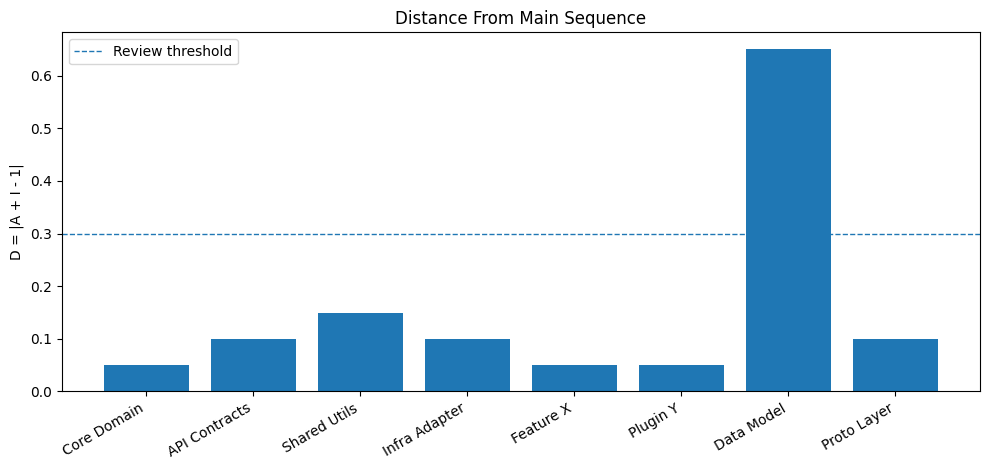

In [59]:
distance = np.abs(A + I - 1)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(module_names, distance)
ax.set_title('Distance From Main Sequence')
ax.set_ylabel('D = |A + I - 1|')
ax.axhline(0.3, linestyle='--', linewidth=1, label='Review threshold')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 🗺️ Where These Metrics Apply

These metrics apply to many software systems:

- large monoliths
- modular applications
- plugin architectures
- libraries
- microservices

Microservice systems especially benefit from coupling analysis because dependencies often hide behind **network calls rather than imports**.

A service with high efferent coupling may rely on many downstream services.

Each dependency increases operational risk.

Understanding coupling helps prevent systems from drifting toward the dreaded:

```text
distributed monolith
```

## 🧱 The Takeaway

Architecture is often treated as an art.

But beneath the diagrams lies something more mechanical.

Software systems obey structural forces.

Coupling is one of them.

And like gravity…

you can ignore it.

But you cannot escape it.

## 📚 References

- Martin, R. C. (1994). *OO Design Quality Metrics: An Analysis of Dependencies.*
- Martin, R. C. (2017). *Clean Architecture.*
- Lakos, J. (1996). *Large-Scale C++ Software Design.*
- Ford, N., Parsons, R., & Kua, P. (2017). *Building Evolutionary Architectures.*